0.06796131 1.7420114 (128, 128)
camera shift: 0.06 -0.07 0.04
camera rotation (deg): 0.2 -0.3 0.3


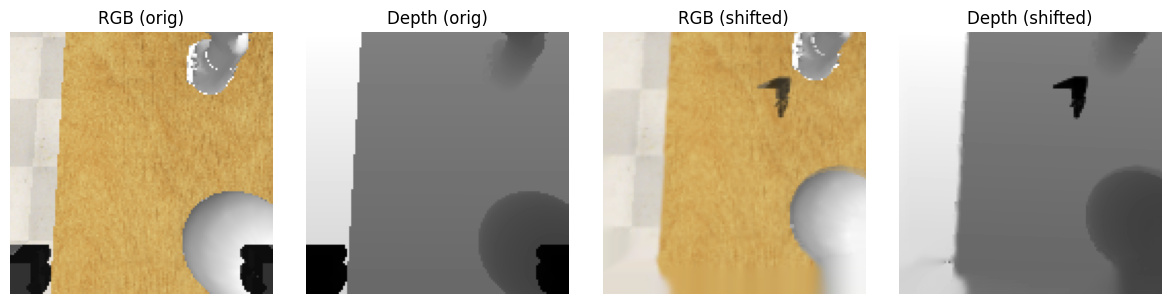

In [21]:
import random
import numpy as np
import matplotlib.pyplot as plt
import cv2
from PIL import Image

import pickle

pkl_path = "/home/zsh/dcoda/data/rlbench_data/train/coordinated_lift_ball_200_demos_128x128/coordinated_lift_ball/all_variations/episodes/episode88/low_dim_obs.pkl"

with open(pkl_path, "rb") as f:
    low_dim = pickle.load(f)
    near = low_dim[20].misc[f'wrist_left_camera_near']
    far = low_dim[20].misc[f'wrist_left_camera_far']

def load_rlbench_depth(path, near=0.01, far=10.0):
    """
    Decode RLBench RGB depth image into metric depth (meters)
    """

    depth_rgb = cv2.imread(path, cv2.IMREAD_UNCHANGED)

    # BGR → RGB
    # depth_rgb = cv2.cvtColor(depth_rgb, cv2.COLOR_BGR2RGB)

    depth_rgb = depth_rgb.astype(np.uint32)

    # 24-bit integer
    depth_int = (
        depth_rgb[:, :, 0] +
        depth_rgb[:, :, 1] * 256 +
        depth_rgb[:, :, 2] * 256 * 256
    )

    depth = depth_int.astype(np.float32) / (256**3 - 1)

    # scale to metric
    depth = near + depth * (far - near)

    return depth

# =========================
# 1. Load depth & RGB
# =========================


depth = np.load('/home/zsh/dcoda/notebooks/captured_images/wrist_right_depth.npy').squeeze(-1) * 10

print(depth.min(), depth.max(), depth.shape)
rgb = cv2.imread(
    '/home/zsh/dcoda/notebooks/captured_images/wrist_right_rgb.png'
)
rgb   = cv2.cvtColor(rgb, cv2.COLOR_BGR2RGB)

H, W = depth.shape

# =========================
# 2. Camera intrinsics
# =========================

K = [[-110.85124795,    0.0,        64.0],
     [   0.0,       -110.85124795,  64.0],
     [   0.0,          0.0,          1.0]]

fx = -K[0][0]
fy = -K[1][1]
cx = K[0][2]
cy = K[1][2]

# =========================
# 3. 6DoF Camera Motion
# =========================

# translation (meters)
delta_X = random.uniform(0.04, 0.08) * random.choice([-1, 1])
delta_Y = random.uniform(0.04, 0.08) * random.choice([-1, 1])
delta_Z = random.uniform(0.04, 0.08) * random.choice([-1, 1])

delta_X = 0.06
delta_Y = -0.07
delta_Z = 0.04

# rotation (degrees)
roll  = np.deg2rad(random.uniform(-0.5, 0.5))    # x-axis
pitch = np.deg2rad(random.uniform(-0.5, 0.5))    # y-axis
yaw   = np.deg2rad(random.uniform(-0.5, 0.5))   # z-axis

# rotation (degrees)
roll  = np.deg2rad(0.2)    # x-axis
pitch = np.deg2rad(-0.3)    # y-axis
yaw   = np.deg2rad(0.3)   # z-axis

print("camera shift:", delta_X, delta_Y, delta_Z)
print("camera rotation (deg):", 
      np.rad2deg(roll), 
      np.rad2deg(pitch), 
      np.rad2deg(yaw))

# =========================
# 4. Euler → Rotation Matrix
# =========================

def euler_to_matrix(roll, pitch, yaw):
    Rx = np.array([
        [1, 0, 0],
        [0, np.cos(roll), -np.sin(roll)],
        [0, np.sin(roll),  np.cos(roll)]
    ])

    Ry = np.array([
        [ np.cos(pitch), 0, np.sin(pitch)],
        [0, 1, 0],
        [-np.sin(pitch), 0, np.cos(pitch)]
    ])

    Rz = np.array([
        [np.cos(yaw), -np.sin(yaw), 0],
        [np.sin(yaw),  np.cos(yaw), 0],
        [0, 0, 1]
    ])

    return Rz @ Ry @ Rx  # ZYX order

R = euler_to_matrix(roll, pitch, yaw)
t = np.array([delta_X, delta_Y, delta_Z])

# =========================
# 5. Init splat buffers
# =========================

rgb_acc   = np.zeros((H, W, 3), dtype=np.float32)
rgb_wacc  = np.zeros((H, W), dtype=np.float32)

invz_acc  = np.zeros((H, W), dtype=np.float32)
invz_wacc = np.zeros((H, W), dtype=np.float32)

zbuf = np.full((H, W), np.inf, dtype=np.float32)

# =========================
# 6. Forward splatting
# =========================

for v in range(H):
    for u in range(W):

        Z = depth[v, u]
        if not np.isfinite(Z) or Z <= 0:
            continue

        # back-project to 3D
        X = (u - cx) * Z / fx
        Y = (v - cy) * Z / fy

        P = np.array([X, Y, Z])

        # 6DoF transform
        Pn = R @ P + t
        Xn, Yn, Zn = Pn

        if Zn <= 0:
            continue

        # re-project
        uf = fx * Xn / Zn + cx
        vf = fy * Yn / Zn + cy

        u0 = int(np.floor(uf))
        v0 = int(np.floor(vf))

        du = uf - u0
        dv = vf - v0

        color = rgb[v, u]
        invZ  = 1.0 / Zn

        weights = [
            (u0,   v0,   (1-du)*(1-dv)),
            (u0+1, v0,   du*(1-dv)),
            (u0,   v0+1, (1-du)*dv),
            (u0+1, v0+1, du*dv)
        ]

        for ui, vi, w in weights:
            if 0 <= ui < W and 0 <= vi < H and w > 0:

                if Zn < zbuf[vi, ui] + 1e-4:
                    zbuf[vi, ui] = Zn

                    rgb_acc[vi, ui]  += color * w
                    rgb_wacc[vi, ui] += w

                    invz_acc[vi, ui]  += invZ * w
                    invz_wacc[vi, ui] += w

# =========================
# 7. Normalize RGB
# =========================

rgb_new = np.zeros_like(rgb_acc)
valid_rgb = rgb_wacc > 1e-6
rgb_new[valid_rgb] = rgb_acc[valid_rgb] / rgb_wacc[valid_rgb, None]
rgb_new = np.clip(rgb_new, 0, 255).astype(np.uint8)

# =========================
# 8. Recover depth
# =========================

depth_new = np.zeros((H, W), dtype=np.float32)
valid_d = invz_wacc > 1e-6
depth_new[valid_d] = invz_wacc[valid_d] / invz_acc[valid_d]

depth_new[depth_new > 8.0] = 0.0

# =========================
# 9. Hole filling
# =========================

hole_mask = (~valid_d).astype(np.uint8) * 255

rgb_new   = cv2.inpaint(rgb_new, hole_mask, 3, cv2.INPAINT_NS)
depth_new = cv2.inpaint(depth_new, hole_mask, 3, cv2.INPAINT_NS)

# =========================
# 10. Save & Visualize
# =========================

Image.fromarray(rgb_new).save("/home/zsh/MVDA/rgb_new.png")
np.save("/home/zsh/MVDA/depth_new.npy", depth_new)

plt.figure(figsize=(12,3))

plt.subplot(1,4,1)
plt.title("RGB (orig)")
plt.imshow(rgb)
plt.axis("off")

plt.subplot(1,4,2)
plt.title("Depth (orig)")
plt.imshow(depth, cmap='gray')
plt.axis("off")

plt.subplot(1,4,3)
plt.title("RGB (shifted)")
plt.imshow(rgb_new)
plt.axis("off")

plt.subplot(1,4,4)
plt.title("Depth (shifted)")
plt.imshow(depth_new, cmap='gray')
plt.axis("off")

plt.tight_layout()
plt.show()